### Laboratorium 09: Przepływ optyczny (ang. *optical-flow*)

To laboratorium obejmuje metodę śledzenia Lucasa-Kanade'a z użyciem przepływu optycznego. Wgraj dostarczone pliki .py oraz .zip a następnie rozpakuj archiwa wykonując kod z poniższej komórki.

In [7]:
import zipfile

#!unzip images.zip
#!unzip ref_imgs.zip

with zipfile.ZipFile('ref_imgs.zip', 'r') as zip_ref:
    zip_ref.extractall()

with zipfile.ZipFile('images.zip', 'r') as zip_ref:
    zip_ref.extractall()

In [2]:
from __future__ import print_function

# Setup
import numpy as np
from skimage import filters
from skimage.feature import corner_peaks
import matplotlib.pyplot as plt
from matplotlib import rc
from IPython.display import HTML

%matplotlib inline
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'


## 0. Wyświetlanie wideo

Na poprzednich laboratoriach realizowaliśmy zadania ze statycznymi obrazami. W tym zadaniu zajmiemy się krótkim wideo, dostarczonym jako szereg czasowy obrazów. Plik utils.py zawiera funkcje narzędziowe do ładowania ramek obrazu i wizualizacji ich jako krótkiego klipu wideo.


RuntimeError: Requested MovieWriter (ffmpeg) not available

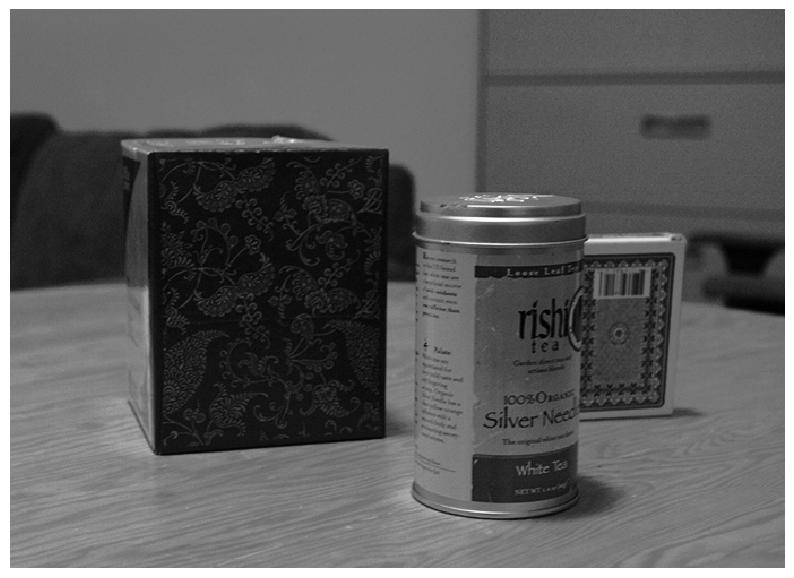

In [3]:
from utils import animated_frames, load_frames
frames = load_frames('images')
ani = animated_frames(frames)
HTML(ani.to_html5_video())

## 1. Metoda Lucasa-Kanade'a przepływu optycznego (*optical flow*)

### 1.1 Wyprowadzenie równania przepływu optycznego
Metody przepływu optycznego służą do szacowania ruchu obiektów między dwiema kolejnymi klatkami obrazu. Na przykład na powyższym filmie puszka herbaty wydaje się poruszać w lewo. Aby nasz system mógł zrozumieć, że puszka porusza się w lewo, przydatne byłoby znalezienie sposobu na dodanie wektorów do puszki (znanych jako wektory przepływu, ang. **flow vectors**), które wskazują kierunek, opisując w ten sposób jej ruch.

Biorąc pod uwagę dwie kolejne klatki, jak możemy znaleźć wektory przepływu dla pierwszej klatki, które opisują sposób poruszania się obiektów między klatkami? Na początek przyjmujemy rozsądne założenie stałości jasności: intensywność piksela poruszającego się punktu pozostaje taka sama między dwiema kolejnymi klatkami z niewielkimi różnicami czasowymi. Innymi słowy, wybierając dowolny piksel poruszającej się puszki, jego jasność pozostaje w przybliżeniu taka sama między klatkami &mdash; jego ruch nie powinien w końcu wpływać na jego jasność.

Rozważmy intensywność piksela (inaczej jasność) $I(x, y, t)$ punktu $(x, y)$ w pierwszej klatce $t$. Załóżmy, że punkt przesunął się do $(x+\Delta{x}, y+\Delta{y})$ po $\Delta{t}$. Zgodnie z założeniem stałości jasności, możemy powiązać intensywności punktu w dwóch klatkach za pomocą następującego równania:

$$
I(x,y,t)=I(x+\Delta{x},y+\Delta{y},t+\Delta{t})
$$

Wracając do przykładu poruszającej się puszki, równanie to po prostu stwierdza, że wybrany przez nas punkt będzie miał taką samą intensywność nawet po przemieszczeniu się w przestrzeni $(\Delta{x}$ i $\Delta{y})$ i między klatkami $(\Delta{t})$. Z tego prostego założenia możemy wyprowadzić równanie przepływu optycznego. Dla danego punktu dla dowolnej klatki, równanie przepływu optycznego jest dane przez:

$$
I_x({\mathbf{p}})v_{x} +
I_y({\mathbf{p}})v_{y} +
I_t({\mathbf{p}})
= 0
$$

Tutaj $I_x$, $I_y$ i $I_t$ są cząstkowymi pochodnymi intensywności piksela $I$. Tymczasem,
$v_{x}$ i $v_{y}$ są wektorami przepływu odpowiednio w kierunku $x-$ i $y-$. Jeśli możemy rozwiązać dla tych dwóch wartości, będziemy w stanie opisać ruch dowolnego obiektu między klatkami.

Być może zastanawiasz się, jak przeszliśmy od założenia stałej jasności do równania przepływu optycznego. Spróbuj wyprowadzić je samodzielnie z równania stałości jasności używając przybliżenia Taylora pierwszego rzędu.

### 1.2 Przegląd metody Lucasa-Kanade'a

Jednym z problemów związanych z równaniem przepływu optycznego jest to, że istnieją dwie niewiadome, które chcemy rozwiązać ($v_x$ i $v_y$).

Metoda Lucasa-Kanade'a rozwiązuje ten problem poprzez dodanie kolejnego założenia: **spójność przestrzenna**.Oznacza to, że ruch zawartości obrazu między dwiema klatkami jest w przybliżeniu stały w sąsiedztwie rozważanego punktu $p$.

Rozważmy sąsiedztwo $p$, $N(p)=\{p_1,...,p_n\}$ (np. okno 3x3 wokół $p$). Dodając założenie spójności przestrzennej do równania przepływu optycznego, widzimy, że powinny być spełnione następujące warunki:

Dla każdego $p_i \ w N(p)$,
$$
I_{x}(p_i)v_x + I_{y}(p_i)v_y = -I_{t}(p_i)
$$

Równania te można zapisać w postaci macierzy $Av=b$, gdzie

$$
A =
\begin{bmatrix}
    I_{x}(p_1) & I_{y}(p_1)\\
    I_{x}(p_2) & I_{y}(p_2)\\
    \vdots & \vdots\\
    I_{x}(p_n) & I_{y}(p_n)
\end{bmatrix}
\quad
v =
\begin{bmatrix}
    v_{x}\\
    v_{y}
\end{bmatrix}
\quad
b =
\begin{bmatrix}
    -I_{t}(p_1)\\
    -I_{t}(p_2)\\
    \vdots\\
    -I_{t}(p_n)
\end{bmatrix}
$$

Możemy teraz rozwiązać wektory przepływu (teraz reprezentowane jako $v$) rozwiązując następujący problem najmniejszych kwadratów: $A^{T}Av=A^{T}b$.

### 1.3 Implementacja metody Lucasa-Kanade'a

W tej sekcji zaimplementujemy podstawową metodę Lucas-Kanade do śledzenia funkcji. Aby to zrobić, musimy najpierw znaleźć punkty kluczowe do śledzenia. Detektor narożników Harrisa jest powszechnie używany do inicjalizacji punktów kluczowych do śledzenia za pomocą metody Lucas-Kanade. Do tego zadania użyjemy  [implementacji `skimage`](http://scikit-image.org/docs/dev/auto_examples/features_detection/plot_corner.html) detektora narożników Harrisa.

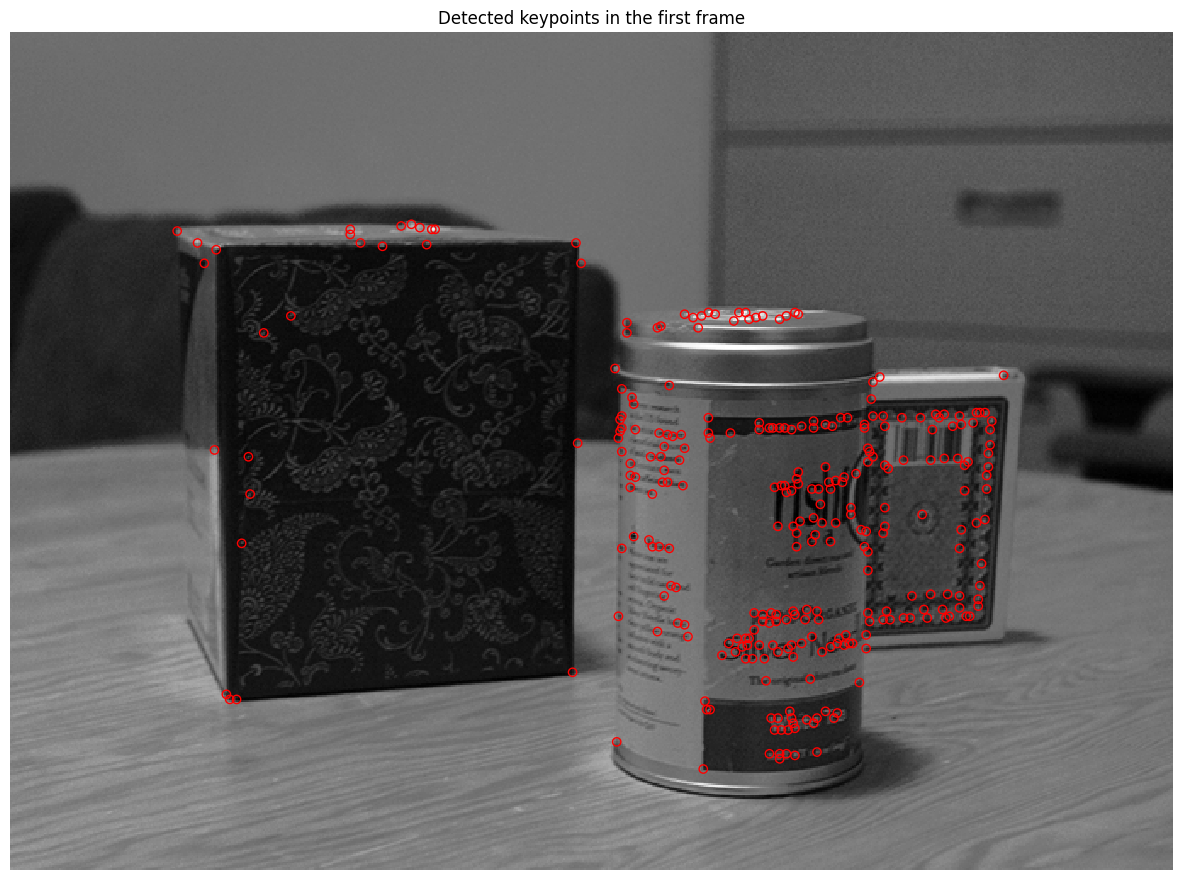

In [4]:
from skimage import filters
from skimage.feature import corner_harris, corner_peaks

frames = load_frames('images')

# Detect keypoints to track
keypoints = corner_peaks(corner_harris(frames[0]),
                         exclude_border=5,
                         threshold_rel=0.01)

# Plot kepoints
plt.figure(figsize=(15,12))
plt.imshow(frames[0])
plt.scatter(keypoints[:,1], keypoints[:,0],
            facecolors='none', edgecolors='r')
plt.axis('off')
plt.title('Detected keypoints in the first frame')
plt.show()

### Zadanie 1. (max 10 pkt)

Zaimplementuj funkcję **`lucas_kanade`** w pliku `motion.py` i uruchom poniższą komórkę kodu. Będziesz mógł zobaczyć małe strzałki wskazujące kierunki, w których poruszają się punkty kluczowe.

Oczekiwany wynik to:
![ref_imgs/optical_flow_vectors.png](ref_imgs/optical_flow_vectors.png)

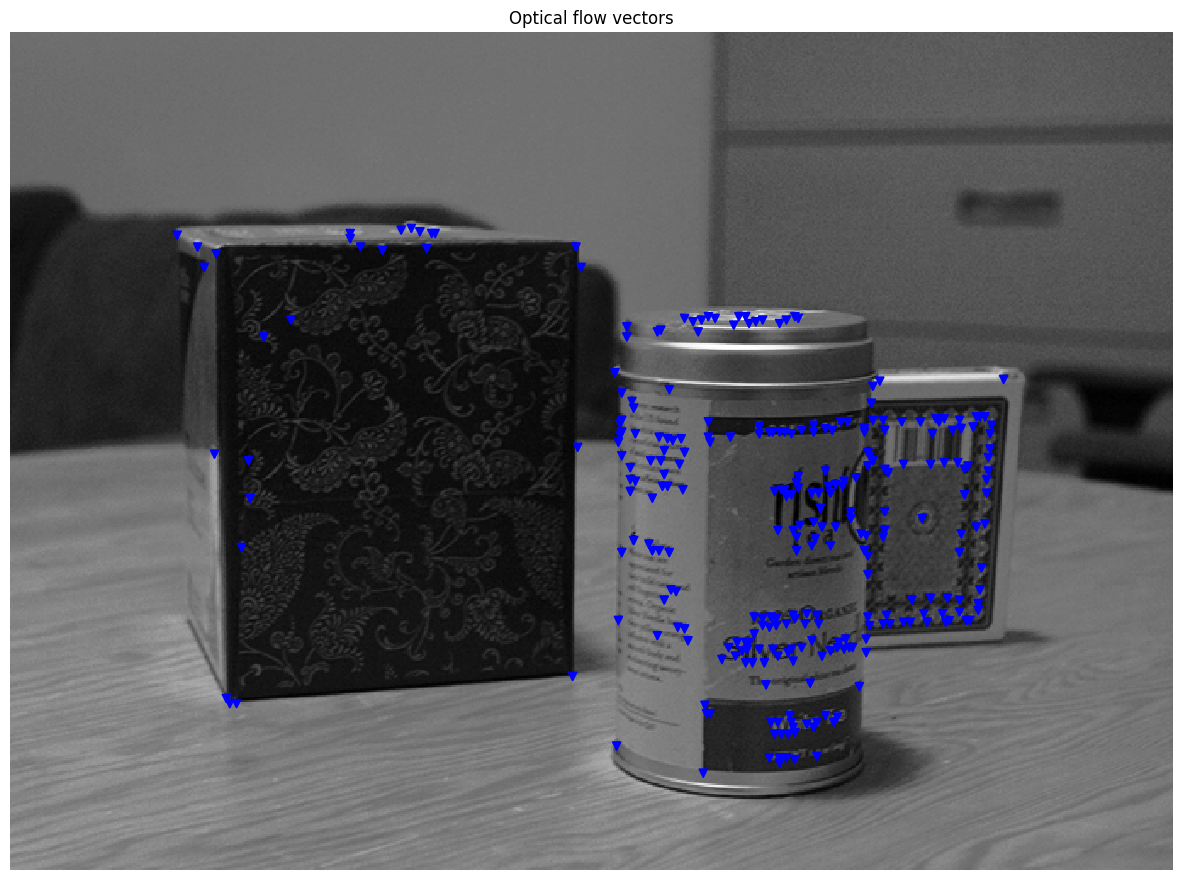

In [5]:
from motion import lucas_kanade

# Lucas-Kanade method for optical flow
flow_vectors = lucas_kanade(frames[0], frames[1], keypoints, window_size=5)

# Plot flow vectors
plt.figure(figsize=(15,12))
plt.imshow(frames[0])
plt.axis('off')
plt.title('Optical flow vectors')

for y, x, vy, vx in np.hstack((keypoints, flow_vectors)):
    plt.arrow(x, y, vx, vy, head_width=5, head_length=5, color='b')


Możemy oszacować pozycję punktów kluczowych w następnej klatce, dodając wektory przepływu do punktów kluczowych.

Oczekiwany wynik to:
![ref_imgs/second_frame_tracked_keypoints.png](ref_imgs/second_frame_tracked_keypoints.png)

In [ ]:
# Plot tracked kepoints
new_keypoints = keypoints + flow_vectors
plt.figure(figsize=(15,12))
plt.imshow(frames[1])
plt.scatter(new_keypoints[:,1], new_keypoints[:,0],
            facecolors='none', edgecolors='r')
plt.axis('off')
plt.title('Tracked keypoints in the second frame')
plt.show()

### 1.4 Śledzenie punktów w wielu klatkach

Teraz możemy użyć metody Lucasa-Kanade'a do śledzenia punktów kluczowych w wielu klatkach. Pomysł jest prosty: oblicz wektory przepływu w punktach kluczowych w $i$-tej klatce i dodaj wektory przepływu do punktów, aby śledzić punkty w $i+1$-tej klatce. Funkcja `track_features` jest już przygotowana. Najpierw uruchom poniższą komórkę kodu. Zauważysz, że niektóre punkty po prostu dryfują i nie są śledzone zbyt dobrze.

Zamiast zachowywać te "złe" ścieżki, chcielibyśmy w jakiś sposób zadeklarować, że niektóre punkty są "utracone" i po prostu je odrzucić. Jednym z prostych sposobów jest porównanie obszarów wokół śledzonych punktów w dwóch kolejnych klatkach. Jeśli obszar wokół punktu NIE jest podobny do obszaru wokół odpowiadającego mu punktu w następnej klatce, wówczas deklarujemy, że punkt został utracony. W tym przypadku użyjemy błędu średniokwadratowego między dwoma znormalizowanymi plamami jako kryterium utraconych ścieżek.

### Zadanie 2. (max 10 pkt)


Zaimplementuj **`compute_error`** w `motion.py` i ponownie uruchom poniższą komórkę kodu. Zobaczysz, że wiele punktów zniknie w późniejszych klatkach.

Ostatnia klatka powinna wyglądać jak:

![ref_imgs/compute_error_final_frame.png](ref_imgs/compute_error_final_frame.png)



In [ ]:
from utils import animated_scatter
from motion import track_features

# Detect keypoints to track in the first frame
keypoints = corner_peaks(corner_harris(frames[0]),
                         exclude_border=5,
                         threshold_rel=0.01)

trajs = track_features(frames, keypoints,
                       error_thresh=1.5,
                       optflow_fn=lucas_kanade,
                       window_size=5)
ani = animated_scatter(frames,trajs)
HTML(ani.to_html5_video())

## 2. Pyramidal Lucas-Kanade Feature Tracker
W tej sekcji zaimplementujemy prostszą wersję metody opisanej w ["Pyramidal Implementation of the Lucas Kanade Feature Tracker"](http://citeseerx.ist.psu.edu/viewdoc/download?doi=10.1.1.185.585&rep=rep1&type=pdf).

### 2.1 Iteracyjna metoda Lucasa-Kanade'a

Jednym z ograniczeń naiwnej metody Lucas-Kanade jest to, że nie może ona śledzić dużych ruchów między klatkami. Być może zauważyłeś, że wynikowe wektory przepływu (niebieskie strzałki) w poprzedniej sekcji są zbyt małe, a śledzone punkty kluczowe są nieco oddalone od miejsca, w którym powinny się znajdować. Aby rozwiązać ten problem, możemy iteracyjnie udoskonalić oszacowane wektory przepływu optycznego. Poniżej znajduje się opis algorytmu krok po kroku:

Niech $p=\begin{bmatrix}p_x & p_y \end{bmatrix}^T$ będzie punktem na obrazie $I$. Celem jest znalezienie wektora przepływu $v=\begin{bmatrix}v_x & v_y \end{bmatrix}^T$ takiego, że $p+v$ jest punktem odpowiadającym $p$ na następnej klatce obrazu $J$.

- Inicjalizacja wektora przepływu:
$$
v=
\begin{bmatrix}
    0\\0
\end{bmatrix}
$$

- Obliczanie macierzy gradientu przestrzennego:
$$
G=\sum_{x=p_x-w}^{p_x+w}\sum_{y=p_y-w}^{p_y+w}
\begin{bmatrix}
    I_{x}^2(x,y) & I_{x}(x,y)I_{y}(x,y)\\
    I_{x}(x,y)I_{y}(x,y) & I_{y}^2(x,y)
\end{bmatrix}
$$

- **for $k=1$ to $K$**
    - Obliczanie różnicy czasowej: $\delta I_k(x, y) = I(x,y)-J(x+g_x+v_x, y+g_y+v_y)$
    - Obliczenie wektora niedopasowania obrazu:
$$
b_k=\sum_{x=p_x-w}^{p_x+w}\sum_{y=p_y-w}^{p_y+w}
\begin{bmatrix}
    \delta I_k(x, y)I_x(x,y)\\
    \delta I_k(x, y)I_y(x,y)
\end{bmatrix}
$$
    - Obliczanie przepływu optycznego: $v^k=G^{-1}b_k$
    - Aktualizacja wektora przepływu dla następnej iteracji: $v := v + v^k$


- Zwróć $v$

### Zadanie 3. (max 15 pkt)

Zaimplementuj metodę `iterative_lucas_kanade` w pliku `motion.py` i uruchom poniższą komórkę kodu. Powinieneś być w stanie zobaczyć nieco dłuższe strzałki w wizualizacji.

Oczekiwany rezultat to:
![ref_imgs/iterative_optical_flow_vectors.png](ref_imgs/iterative_optical_flow_vectors.png)

In [ ]:
from motion import iterative_lucas_kanade

# Run iterative Lucas-Kanade method
flow_vectors = iterative_lucas_kanade(frames[0], frames[1], keypoints)

# Plot flow vectors
plt.figure(figsize=(15,12))
plt.imshow(frames[0])
plt.axis('off')
plt.title('Optical flow vectors (iterative LK)')

for y, x, vy, vx in np.hstack((keypoints, flow_vectors)):
    plt.arrow(x, y, vx, vy, head_width=5, head_length=5, color='b')

Teraz wyrysujemy śledzone punkty kluczowe.

The expected output is:
![ref_imgs/iterative_second_frame_tracked_keypoints.png](ref_imgs/iterative_second_frame_tracked_keypoints.png)

In [ ]:
# Plot tracked kepoints
new_keypoints = keypoints + flow_vectors
plt.figure(figsize=(15,12))
plt.imshow(frames[1])
plt.scatter(new_keypoints[:,1], new_keypoints[:,0],
            facecolors='none', edgecolors='r')
plt.axis('off')
plt.title('Tracked keypoints in the second frame (iterative LK)')
plt.show()

Teraz spróbujemy śledzić punkty kluczowe w różnych klatkach. Poniżej przedstawiono, jak powinna wyglądać końcowa klatka:
![ref_imgs/iterative_compute_error_final_frame.png](ref_imgs/iterative_compute_error_final_frame.png)

In [ ]:
# Detect keypoints to track in the first frame
keypoints = corner_peaks(corner_harris(frames[0]),
                         exclude_border=5,
                         threshold_rel=0.01)

# Track keypoints using iterative Lucas-Kanade method
trajs = track_features(frames, keypoints,
                       error_thresh=1.5,
                       optflow_fn=iterative_lucas_kanade,
                       window_size=5)
ani = animated_scatter(frames,trajs)
HTML(ani.to_html5_video())

---

### Zadanie 4* (max 15 pkt): Coarse-to-Fine Optical Flow

---

Metoda iteracyjna nadal nie była w stanie śledzić większych ruchów. Gdybyśmy zmniejszyli skalę obrazów, większe przemieszczenia stałyby się łatwiejsze do śledzenia. Z drugiej strony, mniejsze ruchy stałyby się trudniejsze do śledzenia, ponieważ stracilibyśmy szczegóły na obrazach. Aby rozwiązać ten problem, możemy reprezentować obrazy w wielu skalach i obliczać wektory przepływu od skali zgrubnej do dokładnej.

Uruchom następującą komórkę kodu, aby zwizualizować piramidę obrazu.

In [ ]:
from skimage.transform import pyramid_gaussian

image = frames[0]

# pyramid_gaussian returns tuple of max_layer + 1 images in multiple scales
pyramid = tuple(pyramid_gaussian(image, max_layer=3, downscale=2))

rows, cols = image.shape
composite_image = np.zeros((rows, cols + cols // 2 + 1), dtype=np.double)
composite_image[:rows, :cols] = pyramid[0]

i_row = 0
for p in pyramid[1:]:
    n_rows, n_cols = p.shape
    composite_image[i_row:i_row + n_rows, cols:cols + n_cols] = p
    i_row += n_rows

# Display image pyramid
plt.figure(figsize=(15,12))
plt.imshow(composite_image)
plt.axis('off')
plt.show()

Poniżej znajduje się opis piramidalnego algorytmu Lucas-Kanade:

Let $p$ be a point on image $I$ and $s$ be the scale of pyramid representation.
- Build pyramid representations of $I$ and $J$: $\{I^L\}_{L=0,...,L_m}$ and $\{J^L\}_{L=0,...,L_m}$


- Initialize pyramidal guess $g^{L_m}=
\begin{bmatrix}g_{x}^{L_m} & g_{y}^{L_m}\end{bmatrix}^T=\begin{bmatrix}0 & 0\end{bmatrix}^T$


- **for $L=L_m$ to $0$ with step of -1**

    - Compute location of $p$ on $I^L$: $p^L=p/s^L$
    
    - Let $d^L$ be the optical flow vector at level $L$:
$$
d^L := IterativeLucasKanade(I^L, J^L, p^L, g^L)
$$
    - Guess for next level $L-1$: $g^{L-1}=s(g^L+d^L)$
    
    
- Return $d=g^0+d^0$

Zaimplementuj `pyramid_lucas_kanade`.

Oczekiwany rezultat:
![ref_imgs/pyramid_optical_flow_vectors.png](ref_imgs/pyramid_optical_flow_vectors.png)

In [ ]:
from motion import pyramid_lucas_kanade

# Lucas-Kanade method for optical flow
flow_vectors = pyramid_lucas_kanade(frames[0], frames[1], keypoints)

# Plot flow vectors
plt.figure(figsize=(15,12))
plt.imshow(frames[0])
plt.axis('off')
plt.title('Optical flow vectors (pyramid LK)')

for y, x, vy, vx in np.hstack((keypoints, flow_vectors)):
    plt.arrow(x, y, vx, vy, head_width=3, head_length=3, color='b')

Teraz wykreślimy śledzone punkty kluczowe.

Oczekiwany wynik to:
![ref_imgs/pyramid_second_frame_tracked_keypoints.png](ref_imgs/pyramid_second_frame_tracked_keypoints.png)

In [ ]:
# Plot tracked kepoints
new_keypoints = keypoints + flow_vectors
plt.figure(figsize=(15,12))
plt.imshow(frames[1])
plt.scatter(new_keypoints[:,1], new_keypoints[:,0],
            facecolors='none', edgecolors='r')
plt.axis('off')
plt.title('Tracked keypoints in the second frame (pyramid LK)')

plt.show()

Teraz spróbujemy śledzić punkty kluczowe w różnych klatkach. Poniżej przedstawiamy, jak powinna wyglądać końcowa klatka:
![ref_imgs/pyramid_compute_error_final_frame.png](ref_imgs/pyramid_compute_error_final_frame.png)

In [ ]:
from utils import animated_scatter
from motion import track_features
keypoints = corner_peaks(corner_harris(frames[0]),
                         exclude_border=5,
                         threshold_rel=0.01)

trajs = track_features(frames, keypoints,
                       error_thresh=1.5,
                       optflow_fn=pyramid_lucas_kanade,
                       window_size=5)
ani = animated_scatter(frames,trajs)
HTML(ani.to_html5_video())

### Opracuj wnioski do sprawozdania odpowiadając na pytania (każde max 3 pkt):

- Dlaczego pojedyncze równanie przepływu optycznego nie wystarcza do wyznaczenia ruchu punktu? Wyjaśnij, jak metoda Lucasa-Kanade’a rozwiązuje ten problem przy użyciu sąsiedztwa punktu.

- Opisz, jak w zaimplementowanej ```funkcji``` lucas_kanade wyznaczane są wektory przepływu dla punktów kluczowych. Jak należy interpretować otrzymane strzałki na wizualizacji?

- Do czego służy funkcja compute_error podczas śledzenia punktów w wielu klatkach? Wyjaśnij, dlaczego część ścieżek jest odrzucana.

- Porównaj podstawową, iteracyjną i piramidalną wersję metody Lucasa-Kanade’a. W jakich sytuacjach każda z nich działa lepiej lub gorzej?

- Znajdź w literaturze przykłady zastosowań przepływu optycznego i opisz zastosowania.

### Zadanie dodatkowe 15 pkt:

Zastosuj jedną z wybranych bibliotek CV do wyznaczenia przepływu optycznego na tych samych danych, przygotuj wizualizację porównującą wyniki

### Skala ocen:

20 pkt - dst, 30 pkt - dst+, 40 pkt - db, 50 pkt - db+, 60 pkt bdb


Przygotowano w oparciu o:

https://github.com/StanfordVL/CS131_release/tree/master